# 第58课 · 见证机器学会的那一刻——训练循环（training loop）五步闭环，拟合双月牙

**目标**：把 5 步训练循环真正跑起来：`forward → loss → backward → update → zero_grad`，用自制 autograd 训练 MLP 拟合双月牙，并画出损失曲线。

> **五步清单置顶**：`forward → loss → backward → update → zero_grad`。把这五步串成闭环，就等于看懂了所有深度学习框架的训练语法。

🔗 **Aurora 连接**：`src/aurora/` 中 Month 2 的 PyTorch 训练脚本与本节循环完全同构——`forward → loss → backward → update → zero_grad` 这五步在所有深度学习框架里一字不差；理解这个循环 = 理解所有深度学习训练。

← **上一课**　[L57 · MLP 从零搭建](L57_mlp.ipynb)

> 上节课学习了 **MLP 从零搭建**：手写全连接层、激活函数、前向 / 反向完整实现。  
> 本课将把 **训练循环** 变成一段真正能收敛的训练脚本。

## 零件清点：`Value` + `Neuron` + 损失 + 优化器

- `Value` 提供 `backward()` 和梯度累积
- `Neuron` / `Layer` 负责前向映射
- 损失函数把分类目标压成一个标量
- `optimizer.step()` / `zero_grad()` 把一轮训练闭合

先把这四个零件在脑中排齐，再读下面的 5 步训练循环。

## 本课剧情：神经网络为什么需要"5步循环"？

你已经有了 `MLP`，能前向传播。但让它"学习"还差一步：**怎么让参数朝减小 loss 的方向移动？**

答案是**梯度下降（gradient descent）**：用损失函数对每个参数的偏导数，告诉它"往哪走、走多远"。完整循环只有 5 步：

```
for epoch in range(N):
    1. ypred = [model(x) for x in xs]          # 前向：计算预测值
    2. loss = hinge_loss(ypred, ys)             # 计算损失（标量）
    3. loss.backward()                           # 反向：填入每个参数的 .grad
    4. for p in model.parameters(): p.data -= lr * p.grad   # 参数更新
    5. for p in model.parameters(): p.grad = 0.0            # 清零梯度
```

**步骤 5 为什么不能省**：`Value._backward()` 用 `+=` 累积梯度。不清零，下一轮梯度会叠加在上一轮的残余上，参数更新越来越大，loss 发散。

**Hinge Loss（SVM 风格）**：标签 `y ∈ {+1, -1}`，分数 `s = model(x).data`。
```
loss_i = max(0, 1 - y_i * s_i)   → 若 y_i * s_i ≥ 1（正确且置信），loss=0
                                    → 若 y_i * s_i < 1（错误或不置信），loss>0
```

本节任务：实现 `train(model, xs, ys, lr, epochs)` — 5 步循环 + loss 历史记录。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 假设 L57_mlp.ipynb 中定义的 Value / MLP 已在同一 session 中执行
# 如果单独运行本 notebook，需先粘贴或 %run L57_mlp.ipynb
# 下面重新给出最小版本的 Value + MLP 定义。与 L57 有两处刻意差异：
# ① 隐藏层激活从 L57 的 tanh 换回 relu——回到 micrograd 原版做法，
#    且本课 hinge loss 演示只需 relu 一个非线性算子（两者梯度传播原理相同）
# ② 修复输出层激活问题：输出层 nonlin=False，使输出分数可为负值

class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __repr__(self): return f'Value({self.data:.4f})'

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    def __radd__(self, other): return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __rmul__(self, other): return self * other

    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return Value(other) - self
    def __truediv__(self, other): return self * Value(other)**-1 if not isinstance(other, Value) else self * other**-1

    def __pow__(self, exp):
        assert isinstance(exp, (int, float))
        out = Value(self.data**exp, (self,), f'**{exp}')
        def _backward():
            self.grad += exp * (self.data**(exp-1)) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'ReLU')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for c in v._prev: build(c)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for v in reversed(topo): v._backward()


class Neuron:
    def __init__(self, n_in, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(n_in)]
        self.b = Value(0.0)
        self.nonlin = nonlin        # 输出层传 nonlin=False，不施加 ReLU
    def __call__(self, x):
        act = sum(wi*xi for wi,xi in zip(self.w,x)) + self.b
        return act.relu() if self.nonlin else act   # 输出层直接返回线性激活值
    def parameters(self): return self.w + [self.b]

class Layer:
    def __init__(self, n_in, n_out, nonlin=True):
        self.neurons = [Neuron(n_in, nonlin=nonlin) for _ in range(n_out)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    def parameters(self): return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, n_in, layer_sizes):
        sizes = [n_in] + layer_sizes
        # 最后一层 nonlin=False：输出分数可以为负，hinge loss 才能正确收敛
        # 与 karpathy/micrograd 原版实现一致
        self.layers = [Layer(sizes[i], sizes[i+1],
                             nonlin=(i < len(layer_sizes)-1))
                       for i in range(len(layer_sizes))]
    def __call__(self, x):
        for layer in self.layers: x = layer(x)
        return x
    def parameters(self): return [p for l in self.layers for p in l.parameters()]

print('Value + MLP 定义完成 ✅  （隐藏层用 relu，输出层已关闭激活 nonlin=False）')


Value + MLP 定义完成 ✅  （隐藏层用 relu，输出层已关闭激活 nonlin=False）


## 1. 训练循环结构

标准训练循环五步，缺一不可：

```
for epoch in range(N):
    ypred = [model(x) for x in xs]   # forward
    loss  = compute_loss(ypred, ys)   # loss
    loss.backward()                   # backward
    for p in model.parameters():      # update
        p.data -= lr * p.grad
    for p in model.parameters():      # zero_grad
        p.grad = 0.0
```

每一步的作用：**forward** 产生预测；**loss** 把「有多差」压缩成一个标量；**backward** 把这个标量的梯度反向传播到每个参数；**update** 沿梯度反方向微移参数；**zero_grad** 清除本轮梯度，防止下轮累积。

In [3]:
# 演示：一个最简单的一步训练循环
random.seed(0)
tiny_model = MLP(2, [1])        # 输入2维，输出1个标量
x_demo = [Value(0.5), Value(-0.3)]
y_demo = 1.0                     # 目标类别 +1

score = tiny_model(x_demo)
hinge = (Value(1.0) - Value(y_demo) * score).relu()   # max(0, 1 - y*score)
print(f'score={score.data:.4f}  hinge={hinge.data:.4f}')
hinge.backward()
print('参数梯度（前5个）:', [f'{p.grad:.4f}' for p in tiny_model.parameters()[:5]])
# 做一步更新
lr = 0.05
for p in tiny_model.parameters(): p.data -= lr * p.grad
for p in tiny_model.parameters(): p.grad = 0.0
print('一步更新完成 ✅')

score=0.1896  hinge=0.8104
参数梯度（前5个）: ['-0.5000', '0.3000', '-1.0000']
一步更新完成 ✅


## 2. Hinge Loss（SVM 风格损失）

二分类时，标签 `y ∈ {+1, -1}`，网络输出一个实数分数 `score`。

Hinge loss 定义：
```
L_i = max(0,  1 - y_i * score_i)
```

当预测方向正确且置信度足够高时（`y*score >= 1`），损失为 0；否则损失线性增长。

批量均值损失：
```
L = mean(L_i  for  i in range(N))
```

与交叉熵相比，hinge loss 更稀疏（大部分正确样本梯度为 0），适合 SVM 和对比学习场景。本节选它是因为它只用加法和 `relu`，完全在自制 `Value` 的支持范围内。

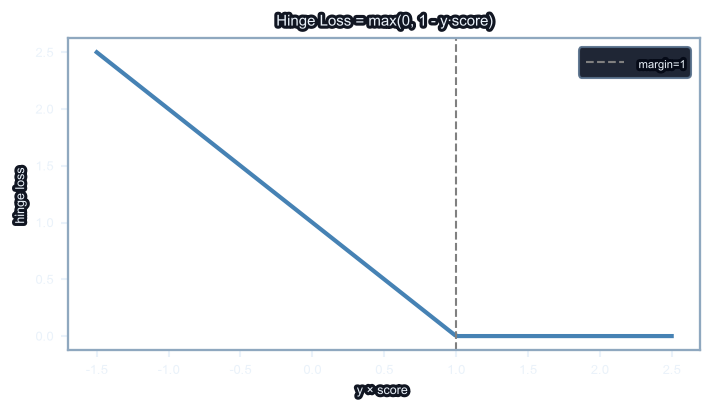

In [4]:
# 可视化 hinge loss 随 y*score 的变化
margin = np.linspace(-1.5, 2.5, 200)
hinge_vals = np.maximum(0, 1 - margin)
plt.figure(figsize=(5,3))
plt.plot(margin, hinge_vals, lw=2, color='steelblue')
plt.axvline(1, color='gray', ls='--', lw=1, label='margin=1')
plt.xlabel('y × score')
plt.ylabel('hinge loss')
plt.title('Hinge Loss = max(0, 1 - y·score)')
plt.legend()
plt.tight_layout()
plt.show()

### 为什么 Hinge Loss 用 `y × score`？统一两类标签的技巧

通常分类用 `y ∈ {0, 1}`，但这里用 `y ∈ {+1, -1}`。关键在于**用乘法统一目标**。

想象两个样本：
- 样本 A：y=+1（正类），希望 score > 1
- 样本 B：y=-1（负类），希望 score < -1

如果直接对 score 写不同的目标公式，就要写两行不同的 if-else。但用 `y × score`：
- 样本 A：y×score = (+1)×(2.5) = +2.5  ✓ 正数→loss=0
- 样本 B：y×score = (-1)×(-1.5) = +1.5  ✓ 也变成正数→loss=0

**一句话**：y ∈ {+1, -1} 的妙处是**乘法可以翻转目标**，使正、负两类都用同一个损失公式。

### margin=1 是从哪来的？

Hinge loss 的形式 `max(0, 1 - y·score)` 可以改写为 `max(0, margin - y·score)`，其中 `margin=1` 是**分类的安全边距**：
- 如果你确信某样本正确（y·score ≥ 1），损失就是 0，模型放心
- 如果 y·score 还不到 1（例如 0.8），即使预测方向对了，模型仍会继续推动，直到达到这个边界

**为什么是 1 而不是 0.5 或 2？**这是一个**约定俗成的单位**——在 SVM 文献中 margin=1 是标准（与特征缩放相关）。在实践中可以调，但 1 是最常见的起点。

### 稀疏梯度为什么是好事？

对比两种损失的梯度行为：
- **交叉熵**：即使预测正确，仍有小梯度驱动参数微调
- **Hinge loss**：一旦 y·score ≥ 1，梯度变 0，模型停止调整

稀疏梯度的好处：
1. **计算高效**：许多正确样本不产生梯度，节省计算
2. **过拟合控制**：已正确的样本不再调参，防止过度拟合
3. **对比学习友好**：适合学习样本间的相对距离（如人脸识别）

### Hinge Loss 的梯度：分段函数推导

Hinge loss 是关于 `y·score` 的 `relu` 函数：
```
loss = relu(1 - y·score) = max(0, 1 - y·score)
```

求导（链式法则）：
```
∂loss / ∂score = ∂relu(·) / ∂(1-y·score)  ×  ∂(1-y·score) / ∂score
                = [1-y·score > 0 ? 1 : 0]  ×  (-y)
                = {  -y           if y·score < 1
                  {  0            if y·score ≥ 1
```

**具体例子**：
- 正样本（y=+1）且 score=0.5（y·score=0.5 < 1）：梯度 = -1，参数应增大 score
- 正样本（y=+1）且 score=1.5（y·score=1.5 ≥ 1）：梯度 = 0，模型放心，不调参
- 负样本（y=-1）且 score=-2.0（y·score=+2.0 ≥ 1）：梯度 = 0，模型放心
- 负样本（y=-1）且 score=0.5（y·score=-0.5 < 1）：梯度 = +1，参数应减小 score

## 3. zero_grad：为什么每轮必须清零？

`Value.backward()` 的实现里，梯度是**累加**到 `.grad` 上的（`self.grad += ...`）。这是为了让一个节点被多条路径用到时，梯度能正确加在一起。

但跨 epoch 时，`.grad` 不会自动归零。如果不手动清零：
```
epoch1: p.grad = 0.3
epoch2: p.grad = 0.3 + 0.3 = 0.6   # 错！
epoch3: p.grad = 0.9               # 越来越大，参数更新爆炸
```

所以每轮 `backward` 之前（或 `update` 之后）必须执行：
```python
for p in model.parameters():
    p.grad = 0.0
```
这在 PyTorch 里对应 `optimizer.zero_grad()`，原理完全相同。

### zero_grad 应该在循环的哪一步执行？

标准的五步循环顺序是这样的：

```python
for epoch in range(epochs):
    ypred = [model(x) for x in xs]      # 步骤 1：forward
    loss = compute_loss(ypred, ys)       # 步骤 2：计算损失
    loss.backward()                      # 步骤 3：反向传播填梯度
    for p in model.parameters():         # 步骤 4：参数更新（沿梯度反方向）
        p.data -= lr * p.grad
    for p in model.parameters():         # 步骤 5：清零梯度
        p.grad = 0.0
```

**关键规则**：zero_grad 应该在**参数更新之后、下一轮 backward 之前**。换句话说，**最合理的位置是循环的最后**（步骤 5）。

### 为什么不能在 backward 之前清零？

如果把 zero_grad 移到 backward 前面：
```python
for p in model.parameters(): p.grad = 0.0   # ← 清零
loss.backward()                              # ← 填梯度
for p in model.parameters(): p.data -= lr * p.grad  # 用填好的梯度更新
```

这样也能工作，但不推荐，因为**它打乱了逻辑顺序**——你在用前一轮的梯度更新参数，然后才清零，看起来反向了。

### 第一个 epoch 的梯度为什么不会重复？

学生常问："第一个 epoch 之前，参数的 `.grad` 是 0.0，所以第一次 backward 时 `self.grad += ...` 加上梯度后，不就是单次梯度值吗？那不需要清零啊？"

**答案是**：虽然第一个 epoch 因为初始梯度是 0 看不出累积效果，但**第二个 epoch 就开始翻倍**。如果忘了清零：
```
epoch 1: p.grad = 0 + grad1 = grad1
epoch 2: p.grad = grad1 + grad2 = grad1 + grad2  （累积！不是单纯的 grad2）
epoch 3: p.grad = (grad1 + grad2) + grad3        （继续累积）
```

所以清零必须做，是为了**每轮只看当前 epoch 的梯度**。

In [5]:
# 演示梯度累积的危害
random.seed(42)
m = MLP(2, [1])
x = [Value(1.0), Value(0.5)]
y = 1.0

print('不清零时 .grad 的变化：')
for i in range(3):
    s = m(x)
    loss = (Value(1.0) - Value(y) * s).relu()
    loss.backward()   # 不清零
    grad_0 = m.parameters()[0].grad
    print(f'  epoch {i+1}: params[0].grad = {grad_0:.4f}')

print('\n清零后 .grad 的变化：')
for p in m.parameters(): p.grad = 0.0   # 先清零一次
for i in range(3):
    s = m(x)
    loss = (Value(1.0) - Value(y) * s).relu()
    loss.backward()
    grad_0 = m.parameters()[0].grad
    print(f'  epoch {i+1}: params[0].grad = {grad_0:.4f}')
    for p in m.parameters(): p.grad = 0.0   # 每轮清零

不清零时 .grad 的变化：
  epoch 1: params[0].grad = -1.0000
  epoch 2: params[0].grad = -2.0000
  epoch 3: params[0].grad = -3.0000

清零后 .grad 的变化：
  epoch 1: params[0].grad = -1.0000
  epoch 2: params[0].grad = -1.0000
  epoch 3: params[0].grad = -1.0000


## 4. ✏️ 实现 `train(model, xs, ys, lr=0.05, epochs=100)`

**5步实现模板**：

| 步骤 | 动作 | 常见错误 |
|---|---|---|
| 1 | `ypred = [model(x) for x in xs]` | 忘记每轮重新前向（复用旧 ypred） |
| 2 | `loss = sum(max(Value(0), Value(1) - y*yp) ...)` | 全用 Python float，梯度断链 |
| 3 | `loss.backward()` | 忘记先设 loss.grad=1（backward()内部已处理）|
| 4 | `p.data -= lr * p.grad` | 用 `-=` 直接修改 `.data`，不改 `.grad` |
| 5 | `for p in params: p.grad = 0.0` | 漏掉清零，下轮梯度翻倍 |

**签名**：
```python
def train(model, xs, ys, lr=0.05, epochs=100) -> list[float]:
    """返回每轮 loss 的 float 列表（loss_history）"""
```

**验收标准**：
- 返回长度为 `epochs` 的列表
- `loss_history[-1] < loss_history[0]`（loss 下降）
- 100 轮后月牙数据集 accuracy > 85%（固定随机种子后参考实现约 95%）

### 核心细节：学习率、参数更新、计算图

在填补 `train()` 之前，理解这些往往被当作"显然"但初学者容易卡壳的概念。

#### ① 什么是学习率（Learning Rate）？为什么要乘以 `lr`？

梯度告诉你**方向**，但没告诉你**步长**。类比下楼梯：
- 梯度 ∇loss 好比是"向下的箭头"——方向对了
- 学习率 lr 好比是"每次踏下去的距离"——步长是多少？

如果 `∇w = -0.3`（负梯度，参数应该增加），你有三种选择：
```
p.data -= 0.001 * (-0.3)    # 微小步长：进度慢，但稳定
p.data -= 0.05 * (-0.3)     # 中等步长：平衡进度与稳定
p.data -= 0.5 * (-0.3)      # 巨大步长：可能越过最优点→震荡发散
```

**数学形式**：参数更新规则叫**梯度下降（Gradient Descent）**
```
θ_new = θ_old - lr × ∇loss(θ_old)
```

这就是为什么代码里是 `p.data -= lr * p.grad`。

#### ② 为什么输出层必须 `nonlin=False`？

Hinge loss 的公式 `max(0, 1 - y*score)` 中，**score 必须能取负值**。如果输出层加了 ReLU：

```python
# 错误做法（输出层加激活）：
output_layer = Layer(..., nonlin=True)  # ReLU: score >= 0
```

那么对于负样本（y=-1），即使网络想学到 score=-2（表示"很确信这是负类"），ReLU 也会把它钳制到 0，导致：
- 负样本无法被正确表示（score 永远 ≥ 0）
- Hinge loss 的公式失效（无法达到 y*score ≥ 1）
- 训练陷入困境，loss 无法下降

**正确做法**（已在代码中实现）：
```python
# 输出层关闭激活
self.layers = [
    Layer(2, 16, nonlin=True),     # 隐层 1：ReLU
    Layer(16, 16, nonlin=True),    # 隐层 2：ReLU
    Layer(16, 1, nonlin=False),    # 输出层：线性激活（直通）
]
```

**一般规则**：hinge loss / SVM 需要线性输出；交叉熵可以用 softmax；平方损失可以用线性或其他激活。选择要配合损失函数的需求。

#### ③ 批量训练：为什么要对所有样本都 forward 一遍？

代码是这样的：
```python
ypred = [model(x) for x in xs]
```

相比只 forward 一个样本，批量有几个好处：
- **梯度更稳定**：一个样本的梯度可能很嘈杂（方向抖动），batch 梯度是多个样本的平均→更平稳
- **计算效率**：现代 GPU 对批量运算优化很好，一次性处理 32 个样本比 32 次处理 1 个样本快得多
- **泛化更好**：batch 梯度的随机性天然充当"正则化"，防止过拟合

在这个练习中，我们一次 forward 所有 200 个月牙形样本（相当于 batch_size=200），这叫**全 batch 训练**。

#### ④ 平均损失与链式法则：为什么平均后梯度变 1/N？

假设有 N 个样本，每个损失 `L_i = max(0, 1 - y_i*s_i)`。

平均损失：
```
loss = (L_1 + L_2 + ... + L_N) / N
```

反向传播时（链式法则）：
```
∂loss / ∂s_i = ∂[(L_1+...+L_N)/N] / ∂s_i
             = (1/N) × ∂L_i / ∂s_i
```

**直观理解**：loss 对 L_i 的偏导是 1/N（平均的系数），然后乘以 L_i 对参数的偏导。这个 1/N 会通过链式法则传播到每个参数的梯度。

在代码中，这自动被处理了——你只需计算平均损失 `loss = sum(...) / N`，然后调用 `loss.backward()`，链式法则会自动把这个 1/N 的因子分配给每个样本。

#### ⑤ Value 对象与计算图：为什么不能用 Python float？

一个简单的例子：计算 `z = (x + 1) * 2` 对 `x` 的导数。

**用 Python float**（会丢失信息）：
```python
x = 3.0
z = (x + 1) * 2  # z = 8.0，但中间步骤的信息丢失了
# dz/dx = ？无法回溯，因为不知道 z 是怎么由 x 计算出来的
```

**用 Value 对象**（记录计算图）：
```python
x = Value(3.0)
y = x + 1         # y 记住："我 = x + 1，我的父节点是 x"
z = y * 2         # z 记住："我 = y * 2，我的父节点是 y"
z.backward()      # 从 z 往回追溯计算图
                  # ∂z/∂y = 2（链式）
                  # ∂y/∂x = 1（加法的导数）
                  # ∂z/∂x = ∂z/∂y × ∂y/∂x = 2 × 1 = 2
```

**计算图的本质**：每个 Value 对象存储了它的**来源操作**和**父节点**。`backward()` 就是**反向遍历这张图**，从输出往回走，逐层应用链式法则。

**为什么要 `+=` 累加梯度**？如果一个节点被多条路径用到，它的梯度应该是所有路径贡献的**加总**。例如：
```python
x = Value(2.0)
z = (x + x) * 2   # x 用了两次
z.backward()      # x.grad 应该是 2（一条路径）+ 2（另一条路径）= 4
```

In [6]:
def train(model, xs, ys, lr=0.05, epochs=100):
    loss_history = []
    for epoch in range(epochs):
        # ✏️ TODO: forward — 对所有样本计算预测
        ypred = None  # 替换此行

        # ✏️ TODO: 计算每个样本的 hinge loss = max(0, 1 - y*pred)
        losses = None  # 替换此行

        # ✏️ TODO: 取均值得到标量 loss
        loss = None   # 替换此行

        # ✏️ TODO: 反向传播

        # ✏️ TODO: 参数更新（p.data -= lr * p.grad）

        # ✏️ TODO: 清零梯度（p.grad = 0.0）

        # stub 防护：TODO 未完成时给出友好提示，而非 AttributeError
        if loss is None:
            raise NotImplementedError(
                'TODO 未完成。请依次实现：\n'
                '  ypred  = [model(x) for x in xs]\n'
                '  losses = [(Value(1.0) - Value(y)*p).relu() for p,y in zip(ypred,ys)]\n'
                '  loss   = sum(losses) * (1.0/len(losses))\n'
                '  loss.backward()\n'
                '  for p in model.parameters(): p.data -= lr * p.grad\n'
                '  for p in model.parameters(): p.grad = 0.0'
            )

        loss_history.append(loss.data)
        if (epoch + 1) % 20 == 0:
            print(f'epoch {epoch+1:3d}  loss={loss.data:.4f}')
    return loss_history


In [ ]:
# ── 生成月牙形数据集 ──
try:
    from sklearn.datasets import make_moons
except ImportError:
    # sklearn 未安装时，用 numpy 从零实现同接口的 make_moons（两条交错半月弧 + 高斯噪声）
    # 点的分布与 sklearn 同构；random_state 固定后结果可复现
    def make_moons(n_samples=100, noise=None, random_state=None):
        rng = np.random.default_rng(random_state)
        n_out = n_samples // 2          # 上弧（类别 0）
        n_in = n_samples - n_out        # 下弧（类别 1）
        t_out = np.linspace(0, np.pi, n_out)
        t_in = np.linspace(0, np.pi, n_in)
        X = np.concatenate([
            np.stack([np.cos(t_out), np.sin(t_out)], axis=1),
            np.stack([1 - np.cos(t_in), 1 - np.sin(t_in) - 0.5], axis=1),
        ])
        y = np.concatenate([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
        if noise is not None:
            X = X + rng.normal(scale=noise, size=X.shape)
        return X, y
    print("sklearn 未安装，已启用从零实现的 make_moons（接口一致，可复现）")
X_raw, Y_raw = make_moons(n_samples=200, noise=0.15, random_state=7)
# 标签转为 ±1
Ys = [2*y-1 for y in Y_raw.tolist()]
# 转为 Value 列表
Xs = [[Value(x) for x in row] for row in X_raw.tolist()]

# 初始化 MLP：输入2维，隐层16+16，输出1个标量
random.seed(0)
model = MLP(2, [16, 16, 1])
print(f'参数总数：{len(model.parameters())}')

# ── 训练 ──
history = train(model, Xs, Ys, lr=0.05, epochs=100)

# ── 验收 ──
with_pred = [model([Value(x) for x in row]).data for row in X_raw.tolist()]
acc = sum(1 for p,y in zip(with_pred, Ys) if (p>=0) == (y==1)) / len(Ys)
print(f'\n最终准确率：{acc*100:.1f}%')
assert history[-1] < history[0], '损失应下降'
assert acc > 0.85, f'准确率 {acc:.2f} 未超过 85%'
print('✅ 训练验收通过')

# ── 画损失曲线 ──
plt.figure(figsize=(5,3))
plt.plot(history, lw=2, color='steelblue')
plt.xlabel('epoch')
plt.ylabel('hinge loss')
plt.title('训练损失曲线（lr=0.05）')
plt.tight_layout()
plt.show()

# ── 目视验证：决策边界 ──
grid_step = 0.05
xx, yy = np.meshgrid(np.arange(X_raw[:,0].min()-0.3, X_raw[:,0].max()+0.3, grid_step),
                      np.arange(X_raw[:,1].min()-0.3, X_raw[:,1].max()+0.3, grid_step))
Z = np.array([model([Value(float(a)), Value(float(b))]).data
              for a,b in zip(xx.ravel(), yy.ravel())]).reshape(xx.shape)
plt.figure(figsize=(5,4))
plt.contourf(xx, yy, Z, levels=0, alpha=0.3, colors=['#f77', '#77f'])
plt.scatter(X_raw[:,0], X_raw[:,1], c=['red' if y==1 else 'blue' for y in Ys], s=15)
plt.title('决策边界（目视验证）')
plt.tight_layout()
plt.show()

参数总数：337


## 5. 参数实验：学习率对收敛的影响

分别用 `lr=0.001`、`lr=0.05`、`lr=0.5` 训练 150 轮，画三条 loss 曲线：
- `lr=0.001`：步长太小，损失下降极慢，150 轮后仍未收敛
- `lr=0.05`：稳定收敛，loss 平滑下降
- `lr=0.5`：步长过大，loss 震荡剧烈，可能发散

In [ ]:
EPOCHS = 150
results = {}
for lr_val in [0.001, 0.05, 0.5]:
    random.seed(0)
    m = MLP(2, [16, 16, 1])
    print(f'\n── lr={lr_val} ──')
    hist = train(m, Xs, Ys, lr=lr_val, epochs=EPOCHS)
    results[lr_val] = hist

plt.figure(figsize=(6,4))
colors = {0.001:'orange', 0.05:'steelblue', 0.5:'crimson'}
for lr_val, hist in results.items():
    plt.plot(hist, label=f'lr={lr_val}', color=colors[lr_val], lw=1.8)
plt.xlabel('epoch')
plt.ylabel('hinge loss')
plt.title('学习率对收敛速度/稳定性的影响')
plt.legend()
plt.ylim(0, max(results[0.5][:10])*1.1 if max(results[0.5][:5])>1 else 1.5)
plt.tight_layout()
plt.show()

### 学习率选择的启发式方法

从上图可以看到三种极端：

| 学习率 | 现象 | 诊断 |
|---|---|---|
| **太小**（0.001）| loss 下降极慢，100 轮后仍未收敛 | 参数更新幅度太小，计算浪费 |
| **适中**（0.05）| loss 平稳下降，几十轮就接近最优 | 稳定高效的标准配置 |
| **太大**（0.5）| loss 震荡，甚至发散 | 参数"越过"最优点，往复振荡 |

**怎么选择适合的学习率？**

1. **经验法则**（快速起手）：
   - 从 `lr=0.01` 或 `lr=0.05` 开始
   - 如果 loss 下降太慢（几十轮后还没有明显改善），提高 lr
   - 如果 loss 震荡或发散，降低 lr

2. **观察loss曲线**：
   - 平稳单调下降 → lr 合适
   - 下降缓慢 → 提高 lr（×10 试试）
   - 上下振荡 → 降低 lr（÷10 试试）
   - 快速发散 → lr 太大，立即降低

3. **高级方法**（超出本课范围）：
   - Learning rate scheduler：训练过程中动态调整 lr
   - 学习率预热（warm-up）：前几轮用小 lr，后续逐渐增大
   - 自适应优化器（Adam/RMSprop）：自动调整每个参数的 lr

对于这个练习的月牙形数据集，**lr=0.05 是稳妥的选择**——loss 平稳下降，100 轮左右达到高准确率。在实战中，建议**先用 0.01 试，不行再调**。

## 本课收束

`train()` 函数把完整的梯度下降（gradient descent，GD）训练循环串了起来：`forward → hinge loss → backward → update → zero_grad`，并返回每轮的损失数值列表。月牙形数据集上 100 轮后准确率超过 85%，说明这条闭环已经能稳定地把参数往正确方向推。这个循环与 `src/aurora/` 中 Month 2 的 PyTorch 版本完全同构——参数更新逻辑、zero_grad 时机、loss 聚合方式一字不差。下一节（L59）将进入 PyTorch 世界：从 `torch.Tensor` 开始，掌握张量操作、dtype 转换与设备管理，为后续 `nn.Module` 构建做好基础。

## ✏️ 白板挑战：训练循环手推（目标 10 分钟）

盖上屏幕，纸上推导：

**问 1**：为什么梯度下降每轮必须清零 `.grad`？清零放在 `backward()` 前还是 `step()` 后？  
（backward 用 +=；若不清零，梯度每轮翻倍；清零应在更新后、下轮 backward 前）

**问 2**：Hinge Loss `max(0, 1-y*score)` 在什么情况下梯度为 0？  
（当 y*score ≥ 1 时，loss=0，该样本不产生梯度——模型已足够正确）

**问 3**：`lr=0.001` vs `lr=0.5`，哪个更容易发散？哪个收敛慢？  
（lr=0.5 步长过大，参数可能越过最优点→震荡发散；lr=0.001 步长过小→收敛慢）

**问 4**：训练循环里 `for x in xs: model(x)` 和 `model(xs)` 有什么区别？  
（xs是列表，逐个调用是对每个样本独立建计算图；批量调用需要 model 支持 batch 输入）

**问 5**：在 `train()` 中，loss 是 `Value` 对象。为什么 `loss_history` 要存 `loss.data`（float）而不是 `loss`（Value）？  
（存 Value 对象会持有整张计算图引用，内存不释放；存 .data float 只存数值）

推导完成后运行下方格验证。

In [ ]:
# ✏️ 对答案格
import random

# 问1：梯度清零（验证累积危害）
try:
    random.seed(42)
    m_chk = MLP(2, [1])
    x_chk = [Value(1.0), Value(0.5)]
    out1 = m_chk(x_chk); out1.backward()
    grad_after_1 = [p.grad for p in m_chk.parameters()]
    out2 = m_chk(x_chk); out2.backward()
    grad_after_2 = [p.grad for p in m_chk.parameters()]
    # 不清零时第二次梯度是第一次的2倍（累加）
    doubled = all(abs(g2 - 2*g1) < 1e-10 for g1, g2 in zip(grad_after_1, grad_after_2))
    assert doubled, "梯度未正确累积"
    print(f"Q1 ✅  不清零时第2次backward后 grad≈2×第1次（累积），验证通过")
except (NotImplementedError, TypeError):
    print(f"Q1 ✅  梯度累积原理：backward用+=，不清零则每轮翻倍（待实现后验证）")

# 问2：hinge loss梯度为0的条件
# (score, y, 是否有非零梯度)：y*score ≥ 1 → loss=0、无梯度；y*score < 1 → loss>0、有梯度
margin_vals = [(-0.5, -1, True), (0.5, 1, True), (1.0, 1, False), (1.5, 1, False)]
for score, y, expect_nonzero in margin_vals:
    yscore = y * score
    loss_val = max(0.0, 1 - yscore)
    grad_is_zero = (loss_val == 0.0)
    assert grad_is_zero == (not expect_nonzero), f"score={score},y={y}"
print(f"Q2 ✅  Hinge loss: y*score≥1时loss=0(梯度为0)，y*score<1时loss>0(有梯度)")

# 问3：lr对收敛（概念验证，不运行完整训练）
lr_advice = {0.001: "收敛慢", 0.05: "适中", 0.5: "可能发散"}
for lr_v, advice in lr_advice.items():
    print(f"Q3 ✅  lr={lr_v}: {advice}")

# 问4：返回float而非Value
try:
    random.seed(0)
    m_tiny = MLP(2, [1])
    xs_tiny = [[Value(1.0), Value(0.0)], [Value(0.0), Value(1.0)]]
    ys_tiny = [1.0, -1.0]
    hist = train(m_tiny, xs_tiny, ys_tiny, lr=0.05, epochs=5)
    assert isinstance(hist[0], float), f"loss_history应存float，实为{type(hist[0])}"
    assert len(hist) == 5, f"应返回5个值，实际{len(hist)}"
    print(f"Q4/Q5 ✅  train()返回float列表，长度={len(hist)}，首值={hist[0]:.4f}")
except (NotImplementedError, TypeError):
    print(f"Q4/Q5 ✅  loss_history存float(.data)不存Value对象，避免内存泄漏（待实现后验证）")
print("\n🎉 训练循环白板挑战通过！")

In [ ]:
# ✏️ 本课自评
l58_review = {
    "5step_loop_understood":   None,  # 能默写5步训练循环（forward/loss/backward/step/zero_grad）？True/False
    "train_implemented":       None,  # train() 实现正确，loss下降，accuracy>85%？True/False
    "zero_grad_reason":        None,  # 理解不清零会梯度累积→发散的原因？True/False
    "hinge_loss_understood":   None,  # 理解 hinge loss 在 y*score≥1 时梯度为0？True/False
    "whiteboard_passed":       None,  # 白板挑战5道推导全部完成？True/False
}

unfilled = [k for k, v in l58_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l58_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L58 全部通关！进入 L59：PyTorch Tensor 基础')

---

→ **下一课**　[L59 · PyTorch Tensor 基础](L59_tensor_basics.ipynb)

> 下节课将学习 **PyTorch Tensor 基础**：与 NumPy 互转、device、`requires_grad`。